# 三维 Make-Moons 分类 — 任务书对应实验

**任务书要求：** 程序生成三维数据集，共 **1000** 个样本、两大类 **C0** 与 **C1**；用其**训练**分类器，再**新生成**与训练**同分布**的 **500** 个样本（**C0** 250、**C1** 250）作为**测试集**。比较 **Decision Trees**、**AdaBoost + Decision Trees** 与 **SVM** 的分类性能，并讨论**为何某些算法在此问题上更好**；其中 **SVM 至少选用三种不同的核函数（kernel）**。

**本笔记本实现：** 从零编写 **Gini 决策树**（支持 `sample_weight`，未用 `sklearn.tree`）、以该树为弱学习器的 **AdaBoost**（未用 `sklearn.ensemble`），以及 **sklearn.svm.SVC**（**linear / rbf / poly** 三种核）。代码中标签 `0` 表示 **C0**，`1` 表示 **C1**。

## 1. 数据生成（与任务书一致）

- **训练集**：1000 点 — **C0** 500、**C1** 500（`noise=0.2`）。
- **测试集**：再次调用同一 `make_moons_3d` 独立抽取 500 点 — **C0** 250、**C1** 250；与训练数据**同分布**且**不参与训练**。
- `np.random.seed(42)`：可复现；训练集生成后再生成测试集，相当于从同一随机源连续采样两次独立数据集。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection

np.random.seed(42)


def make_moons_3d(n_samples=500, noise=0.1):
    """
    生成三维两月牙数据；每类 n_samples 点，共 2*n_samples 行。
    返回标签 y_lab：0 = 任务书中的类 C0，1 = 类 C1。
    """
    t = np.linspace(0, 2 * np.pi, n_samples)
    x = 1.5 * np.cos(t)
    y = np.sin(t)
    z = np.sin(2 * t)
    X = np.vstack([np.column_stack([x, y, z]), np.column_stack([-x, y - 1, -z])])
    y_lab = np.hstack([np.zeros(n_samples), np.ones(n_samples)])
    X += np.random.normal(scale=noise, size=X.shape)
    return X, y_lab


# 训练 1000 点 (C0/C1 各 500)；测试为同程序、同参数下重新采样的 500 点 (C0/C1 各 250)
X_train, y_train = make_moons_3d(n_samples=500, noise=0.2)
X_test, y_test = make_moons_3d(n_samples=250, noise=0.2)

print("Train (1000, C0=0 C1=1):", X_train.shape, np.bincount(y_train.astype(int)))
print("Test  (500,  同分布独立采样):", X_test.shape, np.bincount(y_test.astype(int)))

Train: (1000, 3) (1000,) class counts: [500 500]
Test: (500, 3) (500,) class counts: [250 250]


## 2. 三维数据分布可视化

左：训练集 1000 点（**C0** / **C1**）；右：按任务书**新生成**的测试集 500 点，与训练**同分布**、**独立**采样。

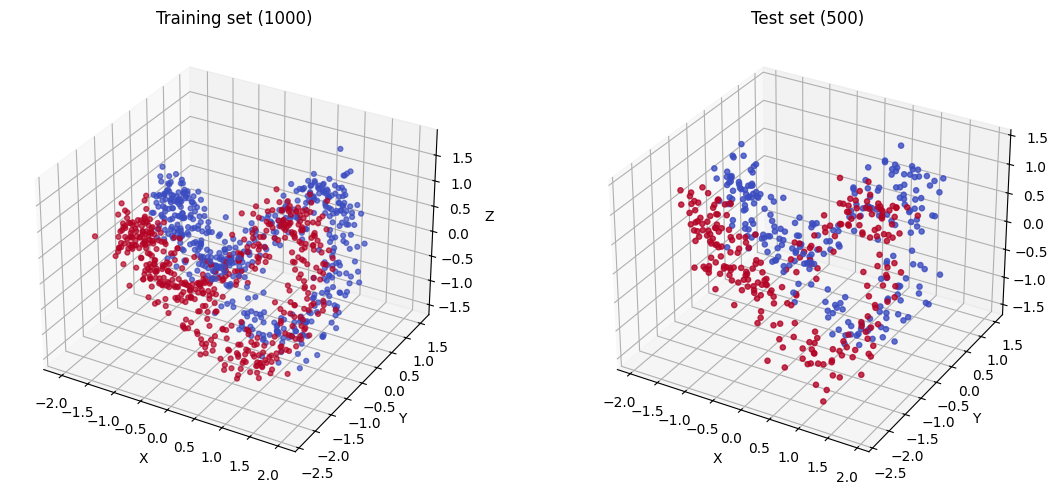

In [ ]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train, cmap="coolwarm", s=12, alpha=0.7)
ax1.set_title("Train: 1000 (C0/C1)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=y_test, cmap="coolwarm", s=14, alpha=0.8)
ax2.set_title("Test: 500 同分布 (C0/C1)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

plt.tight_layout()
plt.show()

## 3. Decision Trees（任务书）— 手动 Gini 决策树

对应任务书中的 **Decision Trees**：本实现**不使用** `sklearn.tree`，用加权 **Gini** 做分裂；标签 $\{0,1\}$ 即 **C0/C1**。

**Weighted Gini impurity** for labels in $\{0,1\}$:

$$
G = 1 - \left(\frac{W_0}{W}\right)^2 - \left(\frac{W_1}{W}\right)^2
$$

where $W_c = \sum_{i: y_i=c} w_i$ and $W = \sum_i w_i$.  
At a candidate split, we minimize the **weighted sum of child Gini values**:

$$
G_{\text{split}} = \frac{W_L}{W} G_L + \frac{W_R}{W} G_R
$$

`sample_weights` 递归传递，供下一节的 **AdaBoost + Decision Trees** 在加权样本上训练弱学习器。

In [ ]:
from typing import List, Optional

def _gini_from_labels(y: np.ndarray, sample_weight: np.ndarray) -> float:
    r"""
    Weighted Gini impurity for binary labels.
    LaTeX: \( G = 1 - \sum_{c \in \{0,1\}} (W_c / W)^2 \),
    with \( W_c = \sum_{i: y_i=c} w_i \), \( W = \sum_i w_i \).
    """
    if y.size == 0:
        return 0.0
    w = sample_weight.astype(np.float64)
    W = np.sum(w)
    if W <= 1e-15:
        return 0.0
    w0 = np.sum(w[y == 0])
    w1 = W - w0
    p0, p1 = w0 / W, w1 / W
    return 1.0 - p0 * p0 - p1 * p1


def _best_weighted_majority_class(y: np.ndarray, sample_weight: np.ndarray) -> int:
    w = sample_weight.astype(np.float64)
    w0 = np.sum(w[y == 0])
    w1 = np.sum(w[y == 1])
    return 0 if w0 >= w1 else 1


class _TreeNode:
    __slots__ = ("feature", "threshold", "left", "right", "value")

    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature  # int or None (leaf)
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # leaf prediction: 0 or 1


class ManualGiniDecisionTree:
    """
    Binary classification tree (y in {0,1}), Gini splits, optional sample weights.
    """

    def __init__(self, max_depth: int = 3, min_weight_fraction_leaf: float = 1e-6):
        self.max_depth = max_depth
        self.min_weight_fraction_leaf = min_weight_fraction_leaf
        self.root_: Optional[_TreeNode] = None

    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight: Optional[np.ndarray] = None) -> "ManualGiniDecisionTree":
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int64).ravel()
        n = X.shape[0]
        if sample_weight is None:
            sw = np.ones(n, dtype=np.float64)
        else:
            sw = np.asarray(sample_weight, dtype=np.float64).ravel()
        sw = sw * (n / np.sum(sw))  # normalize so effective sample size ~ n (stable for depth limits)
        self.root_ = self._build(X, y, sw, depth=0)
        return self

    def _build(self, X, y, sw, depth):
        n = X.shape[0]
        W = np.sum(sw)
        pred = _best_weighted_majority_class(y, sw)

        # Leaf if max depth reached or node is pure (weighted Gini ~ 0)
        if depth >= self.max_depth or _gini_from_labels(y, sw) < 1e-12:
            return _TreeNode(value=pred)

        best_gain = -np.inf
        best_feat, best_thr = None, None
        base_gini = _gini_from_labels(y, sw)

        for j in range(X.shape[1]):
            # Unique thresholds can be huge; use midpoints between sorted distinct values
            col = X[:, j]
            order = np.argsort(col)
            x_sorted = col[order]
            y_sorted = y[order]
            w_sorted = sw[order]
            # candidate thresholds: between consecutive distinct x
            for i in range(n - 1):
                if x_sorted[i] == x_sorted[i + 1]:
                    continue
                thr = 0.5 * (x_sorted[i] + x_sorted[i + 1])
                left_m = x_sorted <= thr  # same order as sorted
                right_m = ~left_m
                W_L = np.sum(w_sorted[left_m])
                W_R = np.sum(w_sorted[right_m])
                if W_L < W * self.min_weight_fraction_leaf or W_R < W * self.min_weight_fraction_leaf:
                    continue
                g_L = _gini_from_labels(y_sorted[left_m], w_sorted[left_m])
                g_R = _gini_from_labels(y_sorted[right_m], w_sorted[right_m])
                g_children = (W_L / W) * g_L + (W_R / W) * g_R
                gain = base_gini - g_children
                if gain > best_gain + 1e-15:
                    best_gain = gain
                    best_feat = j
                    best_thr = thr

        if best_feat is None or best_gain <= 1e-15:
            return _TreeNode(value=pred)

        left_mask = X[:, best_feat] <= best_thr
        right_mask = ~left_mask
        left = self._build(X[left_mask], y[left_mask], sw[left_mask], depth + 1)
        right = self._build(X[right_mask], y[right_mask], sw[right_mask], depth + 1)
        return _TreeNode(feature=best_feat, threshold=best_thr, left=left, right=right)

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        out = np.empty(X.shape[0], dtype=np.int64)
        for i in range(X.shape[0]):
            node = self.root_
            while node.feature is not None:
                if X[i, node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            out[i] = node.value
        return out

## 4. AdaBoost + Decision Trees（任务书）

对应 **AdaBoost + Decision Trees**：**不使用** `sklearn.ensemble`；弱学习器为上一节的 **手动 Gini 决策树**（本实验取 **决策桩** `max_depth=1`）。标签映射 $\{-1,+1\}$：$y^{\pm} = 2y - 1$（**C0**→$-1$，**C1**→$+1$）。弱假设 $h_t(x) \in \{-1,+1\}$（由树输出 0/1 再映射）。

**Weighted error** (normalized):
$$
\varepsilon_t = \frac{\sum_i w_i \, \mathbb{1}[h_t(x_i) \neq y^{\pm}_i]}{\sum_i w_i}
$$

**Learner weight**:
$$
\alpha_t = \frac{1}{2} \ln\frac{1 - \varepsilon_t}{\varepsilon_t}
$$

**Weight update** (multiplicative exponential; same sign as $y \cdot h$ rewards agreement):
$$
w_i \leftarrow w_i \cdot \exp\bigl(-\alpha_t \, y^{\pm}_i \, h_t(x_i)\bigr)
$$

Then normalize $w$ so $\sum_i w_i = 1$.  
**Aggregate classifier**: $H(x) = \mathrm{sign}\bigl(\sum_t \alpha_t h_t(x)\bigr)$.

In [ ]:
class ManualAdaBoost:
    """
    Discrete AdaBoost.M1 with ManualGiniDecisionTree stumps (small max_depth).
    """

    def __init__(self, n_estimators: int = 50, stump_max_depth: int = 1):
        self.n_estimators = n_estimators
        self.stump_max_depth = stump_max_depth
        self.estimators_: List[ManualGiniDecisionTree] = []
        self.alphas_: list[float] = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> "ManualAdaBoost":
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int64).ravel()
        n = X.shape[0]
        y_pm = np.where(y == 0, -1, 1).astype(np.float64)
        w = np.ones(n, dtype=np.float64) / n
        self.estimators_.clear()
        self.alphas_.clear()

        for _ in range(self.n_estimators):
            tree = ManualGiniDecisionTree(max_depth=self.stump_max_depth)
            tree.fit(X, y, sample_weight=w)
            pred01 = tree.predict(X)
            h = np.where(pred01 == 0, -1.0, 1.0)
            wrong = (h != y_pm).astype(np.float64)
            eps = float(np.dot(w, wrong) / (np.sum(w) + 1e-15))
            eps = np.clip(eps, 1e-10, 1.0 - 1e-10)
            if eps >= 0.5:
                break
            alpha = 0.5 * np.log((1.0 - eps) / eps)
            # AdaBoost weight update (LaTeX): \( w_i \leftarrow w_i \exp(-\alpha_t y_i^{\pm} h_t(x_i)) \).
            # Agreement (\(y_i^{\pm} h_t(x_i)=+1\)) shrinks \(w_i\); mistakes grow it.
            w = w * np.exp(-alpha * y_pm * h)
            w /= np.sum(w)
            self.estimators_.append(tree)
            self.alphas_.append(float(alpha))

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self.estimators_:
            raise RuntimeError("AdaBoost not fitted")
        X = np.asarray(X, dtype=np.float64)
        margin = np.zeros(X.shape[0], dtype=np.float64)
        for alpha, tree in zip(self.alphas_, self.estimators_):
            p = tree.predict(X)
            h = np.where(p == 0, -1.0, 1.0)
            margin += alpha * h
        pred_pm = np.sign(margin)
        pred_pm[pred_pm == 0] = 1.0
        return np.where(pred_pm < 0, 0, 1).astype(np.int64)

## 5. 评价指标（在测试集上）

**Accuracy**；**Precision / Recall** 针对 **C1**（标签 `1`，正类）。

In [ ]:
def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(y_true == y_pred))


def precision_recall_binary_positive(y_true, y_pred):
    """Precision and recall for C1 (label 1)."""
    y_true = np.asarray(y_true).ravel().astype(int)
    y_pred = np.asarray(y_pred).ravel().astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return float(prec), float(rec)

## 6. 训练与测试集评估（对应任务书三类方法）

- **Decision Trees**：较深 Gini 树（`max_depth=8`）作为非提升基线。  
- **AdaBoost + Decision Trees**：80 轮、弱学习器为 **决策桩**（`stump_max_depth=1`）。  
- **SVM**：`sklearn.svm.SVC`，任务书要求**至少三种核** — 本实验为 **linear / rbf / poly**。

In [ ]:
from sklearn.svm import SVC

# --- Decision Trees（较深树） ---
tree_clf = ManualGiniDecisionTree(max_depth=8)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

# --- AdaBoost + Decision Trees（决策桩） ---
ada = ManualAdaBoost(n_estimators=80, stump_max_depth=1)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# --- SVM：三种核函数（linear / rbf / poly）---
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_poly = SVC(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1.0, random_state=42)

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)
svm_poly.fit(X_train, y_train)

y_pred_svm_lin = svm_linear.predict(X_test)
y_pred_svm_rbf = svm_rbf.predict(X_test)
y_pred_svm_poly = svm_poly.predict(X_test)

rows = []
for name, yp in [
    ("Decision Trees (Gini, from scratch)", y_pred_tree),
    ("AdaBoost + Decision Trees (stumps)", y_pred_ada),
    ("SVM + linear kernel", y_pred_svm_lin),
    ("SVM + RBF kernel", y_pred_svm_rbf),
    ("SVM + poly kernel", y_pred_svm_poly),
]:
    acc = accuracy_score(y_test, yp)
    prec, rec = precision_recall_binary_positive(y_test, yp)
    rows.append({"Model": name, "Accuracy": acc, "Precision (C1)": prec, "Recall (C1)": rec})

import pandas as pd

df_results = pd.DataFrame(rows)
df_results

,Model,Accuracy,Precision (class 1),Recall (class 1)
0,Decision Tree (manual Gini),0.816,0.813492,0.820
1,AdaBoost (manual + stumps),0.730,0.709091,0.780
2,SVM linear,0.688,0.686508,0.692
3,SVM RBF,0.982,0.980080,0.984
4,SVM poly,0.980,0.980000,0.980


### 结果对比表（任务书：在**同分布测试集**上比较三类方法）

In [ ]:
display_df = df_results.copy()
for col in ["Accuracy", "Precision (C1)", "Recall (C1)"]:
    display_df[col] = display_df[col].map(lambda x: f"{x:.4f}")
print(display_df.to_string(index=False))

                      Model Accuracy Precision (class 1) Recall (class 1)
Decision Tree (manual Gini)   0.8160              0.8135           0.8200
 AdaBoost (manual + stumps)   0.7300              0.7091           0.7800
                 SVM linear   0.6880              0.6865           0.6920
                    SVM RBF   0.9820              0.9801           0.9840
                   SVM poly   0.9800              0.9800           0.9800


---

## 7. 讨论（任务书：为何某些算法表现更好）

以下结合 **C0/C1** 三维月牙的**弯曲几何**与**噪声**，解释 **Decision Trees**、**AdaBoost + Decision Trees**、**SVM（多核）** 的相对优劣；**SVM** 部分对应任务书「至少三种 **kernel**」的要求（本实验为 linear / rbf / poly）。

### Decision Trees：为何在弯曲三维流形上不占优

轴平行分裂对应与坐标面平行的分界面，用长方体区域逼近 **C0/C1** 的**弯曲月牙**需要很多分裂；`noise=0.2` 时边界更易**碎片化**或**过拟合**。因此单独 **Decision Trees** 往往不如能构造**平滑非线性边界**的核 **SVM**。

### AdaBoost + Decision Trees：相对单棵树的改进与局限

相对纯 **Decision Trees**，**AdaBoost + Decision Trees** 通过  
$w_i \leftarrow w_i \exp(-\alpha_t y_i^{\pm} h_t(x_i))$  
**提高**误分样本权重，使下一轮 **决策树（桩）** 更关注难分区域；投票 $\sum_t \alpha_t h_t(x)$ 组合多个弱边界，**分段**逼近月牙。但弱学习器仍是轴平行分裂，且噪声下加权可能不稳定，故未必超过 **RBF/poly 核 SVM**。

### SVM 与三种核：为何非线性核通常更好

任务书要求 **SVM** 至少三种 **kernel**；**线性核**在 $\mathbb{R}^3$ 中仅为**一张超平面**，而 **C0/C1** 月牙经三维嵌入与噪声后通常**线性不可分**，故线性核易**欠拟合**。**RBF 核**依赖局部相似度，边界光滑，贴合**弯曲簇状**几何；**多项式核**也能引入非线性，但形状受次数与系数约束。二者常优于线性核；具体高低与超参 $C,\gamma$ 等有关。